**Import libraries**

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Import Dataset**

In [5]:
from google.colab import files
uploaded = files.upload()

Saving titanic-data.csv to titanic-data.csv


**Load Dataset**

In [6]:
df = pd.read_csv('titanic-data.csv')

**View Data**

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Understand dataset**

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Clean Data**

In [9]:
#check missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
#Fill missing age with average
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_45024/1139141689.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [11]:
#Drop Cabin column(too many missing values)
df.drop('Cabin',axis=1,inplace=True)

In [12]:
# Drop rows where Embarked is missing
df.dropna(subset=['Embarked'], inplace=True)

**Basic analysis**

In [14]:
#Total Passenge
print("Total Passenger:",len(df))

Total Passenger: 889


In [15]:
#Survival Count
print(df['Survived'].value_counts())

Survived
0    549
1    340
Name: count, dtype: int64


**Survival by Gender**

In [16]:
gender_survival = df.groupby('Sex')['Survived'].mean()
print(gender_survival)

Sex
female    0.740385
male      0.188908
Name: Survived, dtype: float64


**Visualization : Survival by Gender**

In [ ]:
gender_survival.plot(kind='bar')
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

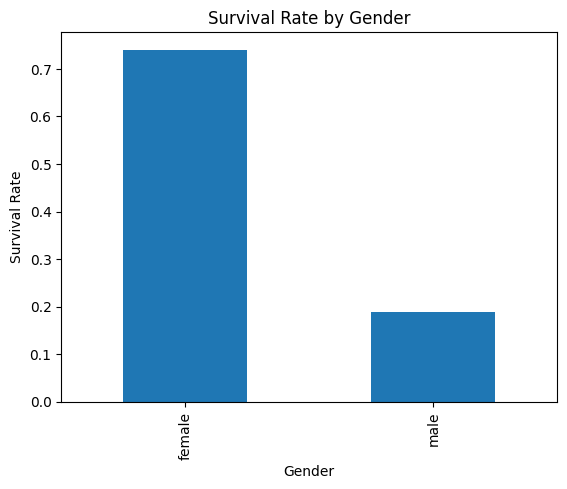

In [20]:
gender_survival.plot(kind='bar')
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

**Survival by Class**

In [19]:
class_survival = df.groupby('Pclass')['Survived'].mean()
print(class_survival)

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


**Visualization : Survival by Class**

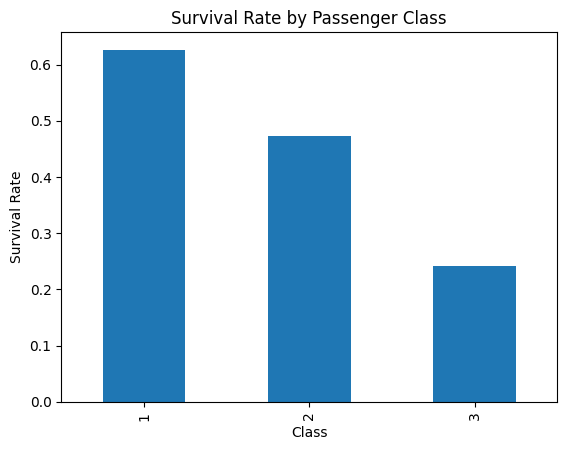

In [21]:
class_survival.plot(kind='bar')
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.show()

In [22]:
# Combined analysis
combined = df.groupby(['Sex','Pclass'])['Survived'].mean()
print(combined)

Sex     Pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64


**Conclusion**

In [ ]:
# 1.Female passengers had significantly higher survival rates than males.
# 2.Passengers in 1st class had the highest survival probability.
# 3.Male passengers in 3rd class had the lowest survival rate.
# 4.Both gender and class played a major role in survival.